# AIMLCZG519 NLP Applications Assignment 2 Training Code

## Team Contribution

| Name of Student     | BITS ID                              | Contribution |
|---------------------|----------------------------------------|-------------|
| K ROMA PAI          | 2024aa05965@wilp.bits-pilani.ac.in    | 100%        |
| JITESH GUPTA        | 2024ab05020@wilp.bits-pilani.ac.in    | 100%        |
| KOTHA AMITABH       | 2024ab05195@wilp.bits-pilani.ac.in    | 100%        |
| JOHIT GARG          | 2024aa05907@wilp.bits-pilani.ac.in    | 100%        |
| KARTHIK REDDY S     | 2024ab05330@wilp.bits-pilani.ac.in    | 100%        |


In [1]:
!pip install datasets nltk scikit-learn tqdm

In [30]:
import pandas as pd
import numpy as np
import re
import nltk
import pickle

from datasets import load_dataset

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
dataset = load_dataset("bdstar/Tweets-Sentiment-Analysis")

# Convert to pandas
train_df = dataset['train'].to_pandas()
test_df = dataset['test'].to_pandas()

train_df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,ID,text,negative,neutral,positive,label
0,1,"How are you, Mr. Ding?",0.0113,0.7568,0.2319,neutral
1,2,Covid cases are increasing fast!,0.7236,0.2287,0.0477,negative
2,3,I don't like it ever!,0.9075,0.0819,0.0106,negative
3,4,Yes That's great. I'm now happy.,0.0049,0.0109,0.9842,positive
4,5,What is this?,0.2209,0.7069,0.0723,neutral


In [5]:
df = pd.concat([train_df, test_df], ignore_index=True)
print("Total samples:", len(df))

Total samples: 2493501


In [6]:
# Use only 20% of the dataset (stratified)

from sklearn.model_selection import train_test_split

df_sampled, _ = train_test_split(
    df,
    test_size=0.9,   # Keep 10%
    stratify=df['label'],
    random_state=42
)

print("Original size:", len(df))
print("Sampled size:", len(df_sampled))

df = df_sampled.reset_index(drop=True)


Original size: 2493501
Sampled size: 249350


In [7]:
from tqdm import tqdm

tqdm.pandas()

In [8]:

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)

    tokens = word_tokenize(text)
    processed_tokens = []

    for word in tokens:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            stem = stemmer.stem(lemma)
            processed_tokens.append(stem)

    return " ".join(processed_tokens)

df['clean_text'] = df['text'].astype(str).progress_apply(preprocess)


100%|██████████| 249350/249350 [00:57<00:00, 4359.65it/s]


In [9]:
df['label'].value_counts()

,count
label,
positive,93483
neutral,82918
negative,72949


In [25]:
vectorizer = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

print("Done")

Done


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (199480, 7000)
X_test shape : (49870, 7000)
y_train shape: (199480,)
y_test shape : (49870,)


In [55]:
print("Initializing optimized models...\n")

lr = LogisticRegression(
    C=2.0,
    max_iter=2000,
    solver='lbfgs',
    class_weight='balanced'
)

print("✔ Logistic Regression initialized")

svm = CalibratedClassifierCV(
    LinearSVC(C=1.5, max_iter=2000),
    method='sigmoid'
)

print("✔ Linear SVM initialized")

nb = MultinomialNB(alpha=0.5)
print("✔ Naive Bayes initialized")

dt = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=20,
    random_state=42
)
print("✔ Decision Tree initialized")

rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)
print("✔ Random Forest initialized")

sgd = SGDClassifier(
    loss='log_loss',
    alpha=1e-4,
    penalty='l2',
    max_iter=2000,
    random_state=42
)
print("✔ SGD Classifier initialized")

print("All 6 models initialized.")

Initializing optimized models...

✔ Logistic Regression initialized
✔ Linear SVM initialized
✔ Naive Bayes initialized
✔ Decision Tree initialized
✔ Random Forest initialized
✔ SGD Classifier initialized
All 6 models initialized.


Starting sequential training of models...



Training Logistic Regression...
Logistic Regression completed
Accuracy: 0.7186
Training Time: 16.81 seconds



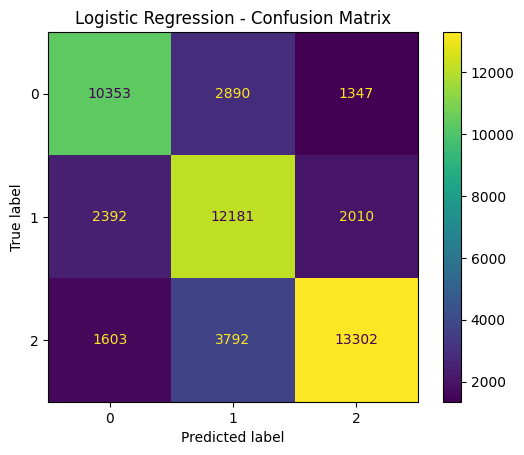



Training Linear SVM...
Linear SVM completed
Accuracy: 0.7188
Training Time: 33.65 seconds



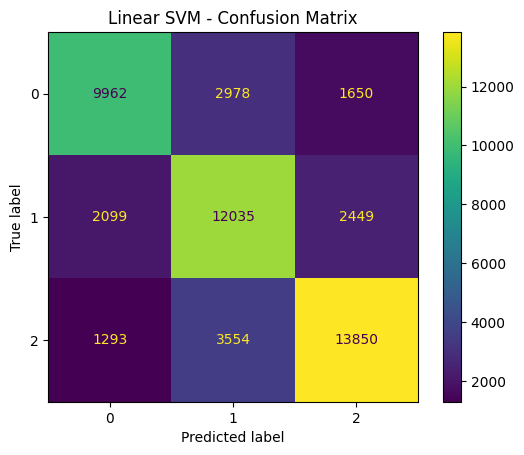



Training Multinomial NB...
Multinomial NB completed
Accuracy: 0.6559
Training Time: 0.44 seconds



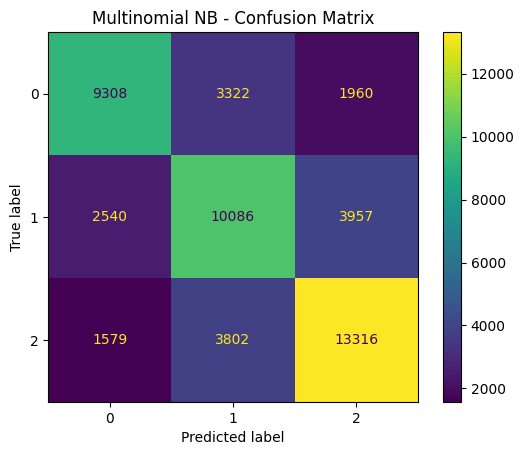



Training SGD Classifier...
SGD Classifier completed
Accuracy: 0.6866
Training Time: 1.21 seconds



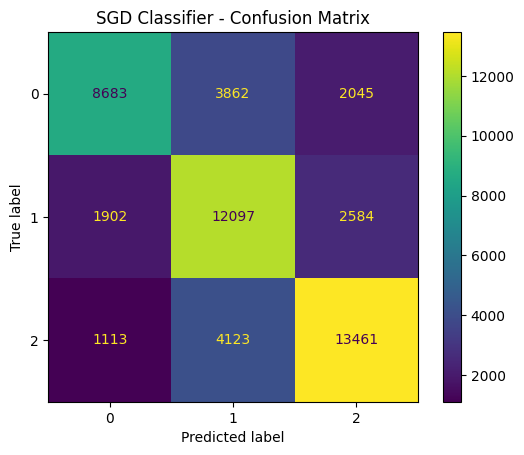



Training Decision Tree...
Decision Tree completed
Accuracy: 0.5215
Training Time: 8.97 seconds



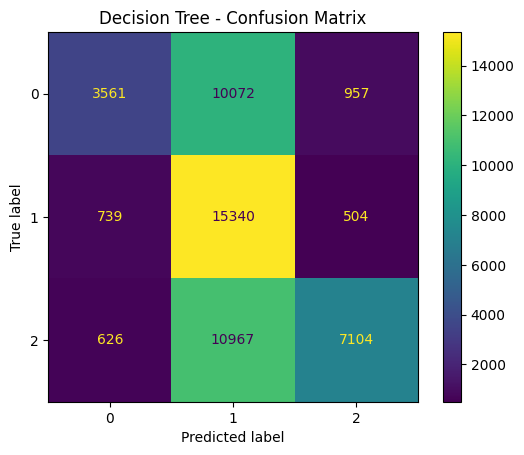



Training Random Forest...
Random Forest completed
Accuracy: 0.5144
Training Time: 2.08 seconds



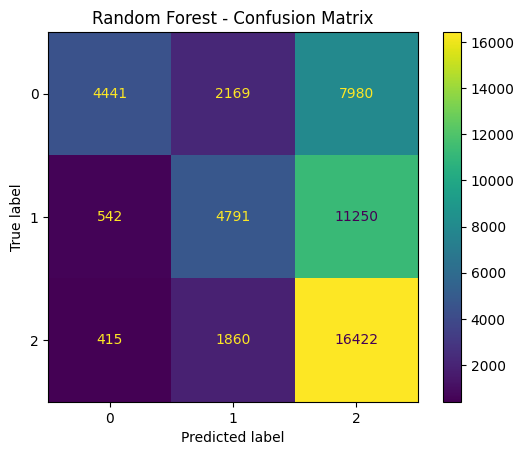

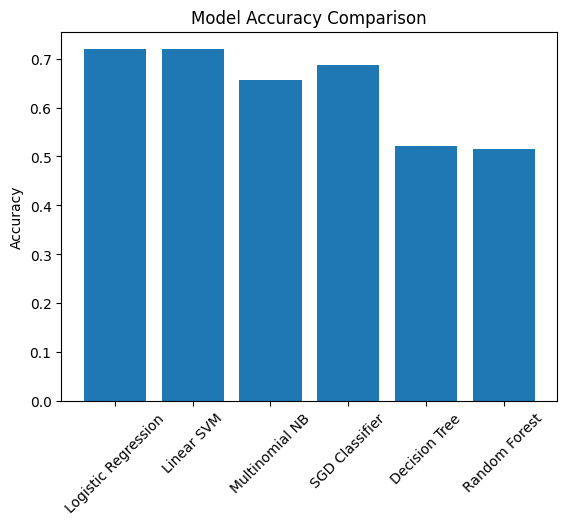

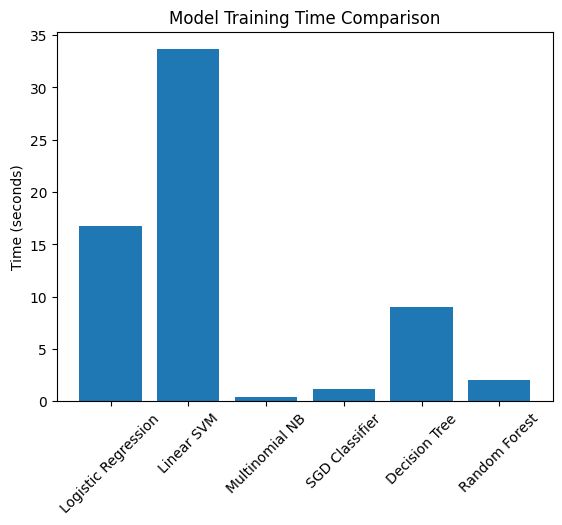

In [56]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

models = {
    "Logistic Regression": lr,
    "Linear SVM": svm,
    "Multinomial NB": nb,
    "SGD Classifier": sgd,
    "Decision Tree": dt,
    "Random Forest": rf
}

results = []

print("Starting sequential training of models...\n")

for name, model in models.items():

    print(f"\n\nTraining {name}...")
    start_time = time.time()

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    duration = time.time() - start_time

    print(f"{name} completed")
    print(f"Accuracy: {acc:.4f}")
    print(f"Training Time: {duration:.2f} seconds\n")

    results.append((name, acc, duration))

    # --- Confusion Matrix Visualization ---
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()


model_names = [r[0] for r in results]
accuracies = [r[1] for r in results]
times = [r[2] for r in results]

print()
plt.figure()
plt.bar(model_names, accuracies)
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

print()
plt.figure()
plt.bar(model_names, times)
plt.xticks(rotation=45)
plt.title("Model Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.show()


In [57]:
print("Building and training Voting Ensemble...\n")

# Build Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('svm', svm),
        ('nb', nb),
        ('sgd', sgd),
        ('dt', dt),
        ('rf', rf)
    ],
    voting='soft',
    weights=[3, 3, 2, 3, 1, 1]
)

# Train
ensemble.fit(X_train, y_train)

print("Ensemble training complete.\n")

# Predictions
ensemble_preds = ensemble.predict(X_test)
ensemble_acc = accuracy_score(y_test, ensemble_preds)

print(f"Ensemble Accuracy: {ensemble_acc:.4f}\n")


Building and training Voting Ensemble...

Ensemble training complete.

Ensemble Accuracy: 0.7184



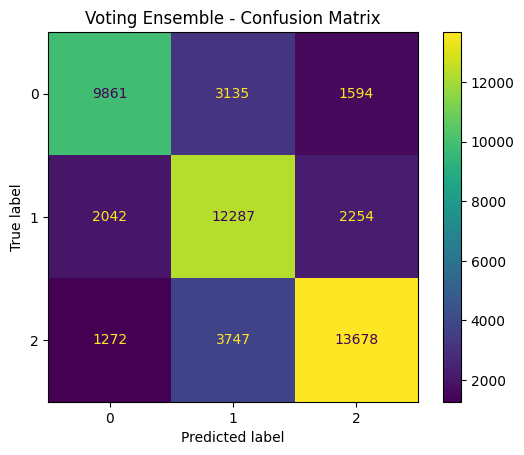

In [58]:
# ===============================
# Confusion Matrix
# ===============================

cm = confusion_matrix(y_test, ensemble_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Voting Ensemble - Confusion Matrix")
plt.show()


In [59]:
# ===============================
# Classification Report
# ===============================

print("Classification Report:\n")
print(classification_report(y_test, ensemble_preds))

Classification Report:

              precision    recall  f1-score   support

    negative       0.75      0.68      0.71     14590
     neutral       0.64      0.74      0.69     16583
    positive       0.78      0.73      0.76     18697

    accuracy                           0.72     49870
   macro avg       0.72      0.72      0.72     49870
weighted avg       0.72      0.72      0.72     49870



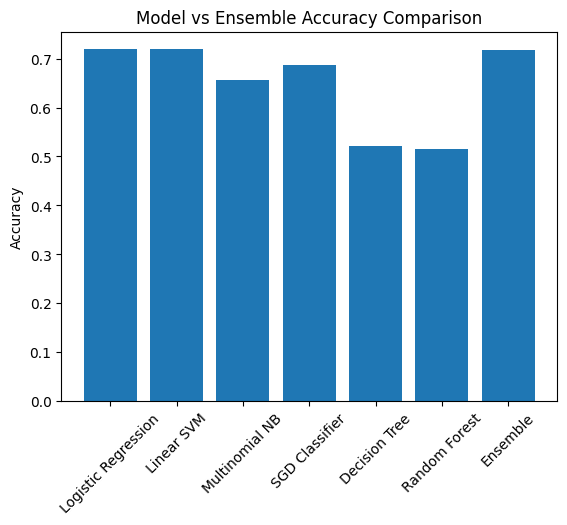

In [60]:
# ===============================
# Accuracy Comparison
# ===============================

# Assuming 'results' list exists from previous model training
model_names = [r[0] for r in results]
accuracies = [r[1] for r in results]

model_names.append("Ensemble")
accuracies.append(ensemble_acc)

plt.figure()
plt.bar(model_names, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model vs Ensemble Accuracy Comparison")
plt.show()

In [61]:
y_pred = ensemble.predict(X_test)

print("Ensemble Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Ensemble Accuracy: 0.7183878083015841

Classification Report:

              precision    recall  f1-score   support

    negative       0.75      0.68      0.71     14590
     neutral       0.64      0.74      0.69     16583
    positive       0.78      0.73      0.76     18697

    accuracy                           0.72     49870
   macro avg       0.72      0.72      0.72     49870
weighted avg       0.72      0.72      0.72     49870



In [62]:
pickle.dump(ensemble, open("ensemble_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

print("Model and vectorizer saved successfully!")


Model and vectorizer saved successfully!


In [63]:
# Load the saved model and vectorizer
model = pickle.load(open("ensemble_model.pkl", "rb"))
vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)

    tokens = word_tokenize(text)
    processed_tokens = []

    for word in tokens:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            stem = stemmer.stem(lemma)
            processed_tokens.append(stem)

    return " ".join(processed_tokens)

def predict_sentence(sentence):
    """
    Processes a sentence and returns:
    - prediction
    - confidence (%)
    - full probability array
    """

    # Preprocess (using your existing function unchanged)
    clean_sentence = preprocess_text(sentence)

    # Vectorize
    vectorized_sentence = vectorizer.transform([clean_sentence])

    # Predict
    prediction = model.predict(vectorized_sentence)[0]

    # Probabilities
    probabilities = model.predict_proba(vectorized_sentence)[0]

    # Confidence (highest probability in %)
    confidence = max(probabilities) * 100

    return prediction, confidence, probabilities

def test_model():
  # Example sentences for testing
  new_sentences = [
    "I love this product, it's absolutely fantastic!",
    "This is the worst experience ever, completely disappointed.",
    "The service was okay, nothing special.",
    "I'm feeling very happy today.",
    "This movie was a waste of time."
  ]

  print("Testing the ensemble model with new sentences:")
  print("=" * 50)
  for sentence in new_sentences:
      # Preprocess the sentence
      prediction, confidence, probabilities = predict_sentence(sentence)

      print(f"\nSentence: {sentence}")
      print(f"Predicted Sentiment: {prediction}")
      print(f"Confidence Score: {confidence:.4f}%")
      print(f"Probabilities: {probabilities}")
      print("=" * 50)

test_model()

Testing the ensemble model with new sentences:

Sentence: I love this product, it's absolutely fantastic!
Predicted Sentiment: positive
Confidence Score: 92.3939%
Probabilities: [0.04235912 0.03370211 0.92393878]

Sentence: This is the worst experience ever, completely disappointed.
Predicted Sentiment: negative
Confidence Score: 81.6348%
Probabilities: [0.8163478  0.07931191 0.10434029]

Sentence: The service was okay, nothing special.
Predicted Sentiment: neutral
Confidence Score: 44.3492%
Probabilities: [0.17361749 0.44349159 0.38289092]

Sentence: I'm feeling very happy today.
Predicted Sentiment: positive
Confidence Score: 55.2548%
Probabilities: [0.40273751 0.04471496 0.55254753]

Sentence: This movie was a waste of time.
Predicted Sentiment: negative
Confidence Score: 60.7284%
Probabilities: [0.60728412 0.21231383 0.18040205]


In [64]:
from google.colab import files

files.download("ensemble_model.pkl")
files.download("tfidf_vectorizer.pkl")
print("Done")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done
